# 0. Import and set up

In [13]:
import os
import time
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # parallel + progress



import shutil
from pathlib import Path
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

# Force edge labels and ticks to automatically shift color based on background
plt.rcParams.update({
    "figure.facecolor": (0, 0, 0, 0),  # Alpha = 0 (Transparent background)
    "axes.facecolor": (0, 0, 0, 0),    # Alpha = 0 (Transparent plot area)
    "savefig.facecolor": (0, 0, 0, 0),
    "text.color": "white",              # Auto-detects text contrast
    "axes.edgecolor": "gray",          # Neutral borders that work on both
    "xtick.color": "gray",
    "ytick.color": "gray",
    "axes.labelcolor": "gray"          # Muted gray labels look great on black or white
})

import sys
sys.path.append("../scripts")
DATA_PATH = "../data/"

from helper_functions import compute_hash, show_duplicates, show_random_samples
%load_ext autoreload
%autoreload 2




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0.1 Datasets configuration



Before proceeding, please verify that you have the necessary datasets in your working directory.
If starting from scratch, download these datasets:

- Kaggle - hasnainjaved/melanoma-skin-cancer-dataset: https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
- ISIC 2016 - https://challenge.isic-archive.com/data/#2016
- ISIC 2020 - https://challenge.isic-archive.com/data/#2020 

Download and set the path below accordingly.
If you download the combined dataset, move to section 0.3

### 0.1.1 Download and combine data

In [ ]:
# If datasets downloaded from Kaggle, set the path to the downloaded datasets here. 
kaggle_10000path = os.path.join(DATA_PATH, "kaggle/")
ISIC2016_image_dir = os.path.join(DATA_PATH,"ISIC2016/images/")
ISIC2016_label_path = os.path.join(DATA_PATH,"ISIC2016/ISIC2016_GroundTruth.csv")
ISIC2020_image_dir = os.path.join(DATA_PATH,"ISIC2020/images/")
ISIC2020_label_path = os.path.join(DATA_PATH,"ISIC2020/ISIC2020_GroundTruth.csv")

In [ ]:
# CONFIGURATION & HELPER FUNCTIONS
from helper_functions import collect_kaggle_images
import shutil 
output_dir = os.path.join(DATA_PATH, "all_images")
output_csv = os.path.join(DATA_PATH, "combined_labels.csv")
os.makedirs(output_dir, exist_ok=True)

# LOAD DATASETS

# --- KAGGLE ---
kaggle_df = pd.concat([
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "benign"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "malignant"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "benign"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "malignant")
], ignore_index=True)

# --- ISIC 2016 ---
isic16_df = pd.read_csv(ISIC2016_label_path, names=["image_id", "label"])
isic16_df["file_path"] = isic16_df["image_id"].apply(lambda x: os.path.join(ISIC2016_image_dir, f"{x}.jpg"))
isic16_df = isic16_df[isic16_df["file_path"].apply(os.path.exists)]

# --- ISIC 2020 ---
isic20_df = pd.read_csv(ISIC2020_label_path, header=0)
isic20_df["file_path"] = isic20_df["image_name"].apply(lambda x: os.path.join(ISIC2020_image_dir, f"{x}.jpg"))
isic20_df = isic20_df[isic20_df["file_path"].apply(os.path.exists)]
isic20_df["label"] = isic20_df["benign_malignant"]


# DATASET STATISTICS

print("--- DATASET STATS ---")
print(f"KAGGLE: total = {len(kaggle_df)} | benign = {len(kaggle_df[kaggle_df['label']=='benign'])} | malignant = {len(kaggle_df[kaggle_df['label']=='malignant'])}")
print(f"ISIC 2016: total = {len(isic16_df)} | benign = {len(isic16_df[isic16_df['label']=='benign'])} | malignant = {len(isic16_df[isic16_df['label']=='malignant'])}")
print(f"ISIC 2020: total = {len(isic20_df)} | benign = {len(isic20_df[isic20_df['label']=='benign'])} | malignant = {len(isic20_df[isic20_df['label']=='malignant'])}")
print("-" * 21)

# MERGE & EXPORT

# Combine all dataframes
combined_df = pd.concat([
    isic16_df[["file_path", "label"]],
    kaggle_df[["file_path", "label"]],
    isic20_df[["file_path", "label"]]
], ignore_index=True)

# Generate unique filenames and copy files over
combined_df["new_filename"] = combined_df.index.astype(str).str.zfill(6) + ".jpg"

print("Copying images to centralized folder...")
for _, row in combined_df.iterrows():
    dest_path = os.path.join(output_dir, row["new_filename"])
    shutil.copy(row["file_path"], dest_path)

# Save the final dataset
combined_df[["new_filename", "label"]].to_csv(output_csv, index=False)

print(f"\nDone ! Total merged images: {len(combined_df)}")
print(f"Images saved to: {output_dir}")
print(f"CSV labels saved to: {output_csv}")

### 0.1.2 Rezising

In [ ]:
# Resizing to max of 1000 pixels on one side.
from helper_functions import resize

image_paths = glob(DATA_PATH+"all_images/*.jpg")  # or your specific path

resized_flags = process_map(
    lambda img: resize(img, max_size=1000, save_over=True), # Wrap it here
    image_paths,
    max_workers=6,
    chunksize=32,
    desc="Resizing large images"
)

resized_count = sum(resized_flags)

print(f"Resized {resized_count} oversized images.")


### 0.1.3 Remove duplicates

Hashes already exist in CSV, skipping recomputation.
Found 5098 hash groups with duplicates (10311 total images).


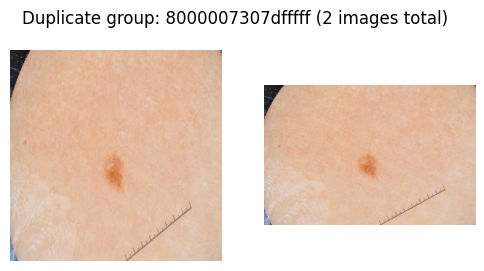

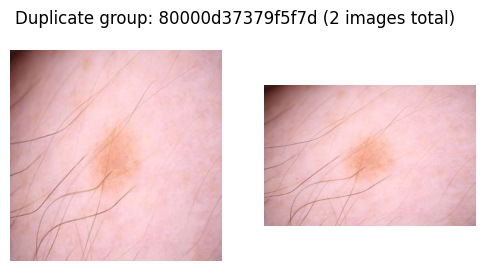

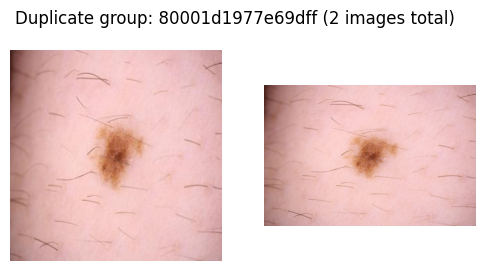

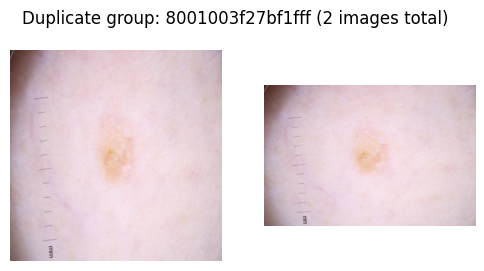

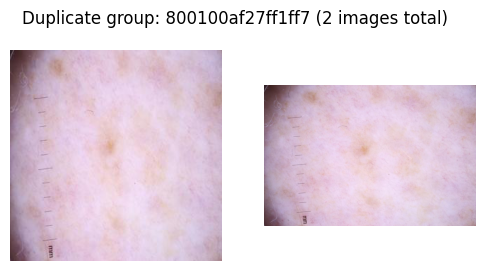

Deleting 5213 duplicates in parallel...


Deleting duplicates: 100%|██████████| 5213/5213 [00:01<00:00, 4446.76it/s]


Removed 5213 duplicate images and updated CSV.
Removed 5213 duplicate images (kept one per group).


In [ ]:
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from helper_functions import compute_hash, show_duplicates

output_csv = os.path.join(DATA_PATH, "combined_labels.csv")
combined_df = pd.read_csv(output_csv)
combined_df["file_path"] = combined_df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))

# === Compute image hashes only if missing ===
if "hash" not in combined_df.columns or combined_df["hash"].isnull().any():
    print("Computing image hashes in parallel...")
    
    # Extract file paths to a list for the executor
    file_paths = combined_df["file_path"].tolist()
    hashes = [None] * len(file_paths)
    
    # Use ProcessPoolExecutor to use all CPU cores
    
    with ProcessPoolExecutor(max_workers=None) as executor:
        # Submit all tasks
        future_to_idx = {executor.submit(compute_hash, fp): i for i, fp in enumerate(file_paths)}
             
        for future in tqdm(as_completed(future_to_idx), total=len(file_paths), desc="Hashing images"):
            idx = future_to_idx[future]
            try:
                hashes[idx] = future.result()
            except Exception as e:
                print(f"Error hashing file index {idx}: {e}")
                hashes[idx] = None

    
    combined_df["hash"] = hashes
    combined_df = combined_df.dropna(subset=["hash"])
    combined_df.to_csv(output_csv, index=False)
    print("Hashes saved to CSV.")
else:
    print("Hashes already exist in CSV, skipping recomputation.")

# === Find duplicates by hash ===
dupe_hashes = combined_df[combined_df.duplicated('hash', keep=False)]
dupe_counts = dupe_hashes['hash'].value_counts()
print(f"Found {len(dupe_counts)} hash groups with duplicates ({dupe_hashes.shape[0]} total images).")
# Show samples of duplicates for sanity check
show_duplicates(combined_df, max_per_group=5)

# === Delete duplicate image files in parallel ===
dupes = combined_df[combined_df.duplicated("hash", keep="first")]
dupe_paths = dupes["file_path"].tolist()

if dupe_paths:
    print(f"Deleting {len(dupe_paths)} duplicates in parallel...")
    
    # Deleting files is mostly I/O bound, so ThreadPool or ProcessPool both work fine here.
    with ProcessPoolExecutor() as executor:
        # os.remove returns None, so we just map the function directly
        futures = {executor.submit(os.remove, fp): fp for fp in dupe_paths}
        
        for future in tqdm(as_completed(futures), total=len(dupe_paths), desc="Deleting duplicates"):
            fp = futures[future]
            try:
                future.result()
            except FileNotFoundError:
                pass # Already deleted or missing
            except Exception as e:
                print(f"Error deleting {fp}: {e}")

# === Drop rows for deleted images ===
clean_df = combined_df.drop_duplicates(subset="hash", keep="first")

# === Save cleaned CSV ===
clean_df.to_csv(output_csv, index=False)
print(f"Removed {len(dupes)} duplicate images and updated CSV.")

# === Show how many were dropped ===
n_removed = len(combined_df) - len(clean_df)
print(f"Removed {n_removed} duplicate images (kept one per group).")

### 0.1.4 Final dataset path

In [16]:
output_csv = DATA_PATH+"./combined_labels.csv"
df = pd.read_csv(output_csv)
df["file_path"] = df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))
print(len(df))

39418


# 1. Dataset properties

## 1.1 Class distribution

In [10]:
from IPython.display import display, HTML

# 1. Format the value counts into a clean DataFrame
dist_df = df['label'].value_counts().to_frame().reset_index()
dist_df.columns = ['Class Label', 'Count']

# 2. Add a clean, bold Markdown header above the table
display(HTML("<h3>Class Distribution</h3>"))
display(dist_df)


,Class Label,Count
0,benign,34196
1,malignant,5222


## 1.2 Color Distribution

Checking for outliers if there are any

In [11]:
import numpy as np
from tqdm.contrib.concurrent import thread_map
from PIL import Image

def average_rgb_safe(img_path):
    try:
        with Image.open(img_path) as img:
            return np.array(img.convert('RGB')).mean(axis=(0,1))
    except Exception as e:
        return np.array([0.0, 0.0, 0.0])

results = thread_map(
    average_rgb_safe, 
    df['file_path'].tolist(), 
    max_workers=8,
    desc="Threading average color"
)

colors = np.array(results)



Threading average color:   0%|          | 0/39418 [00:00<?, ?it/s]

KeyboardInterrupt: 

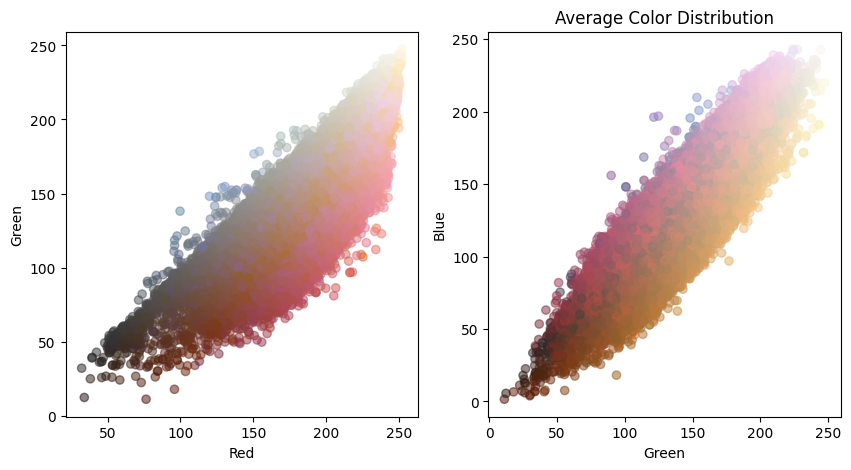

In [34]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(colors[:,0], colors[:,1], c=colors/255, alpha=0.5)
axs[0].set_xlabel("Red")
axs[0].set_ylabel("Green")
axs[1].scatter(colors[:,1], colors[:,2], c=colors/255, alpha=0.5)
axs[1].set_xlabel("Green")
axs[1].set_ylabel("Blue")
plt.title("Average Color Distribution")
plt.show()


## 1.3 Visual check up

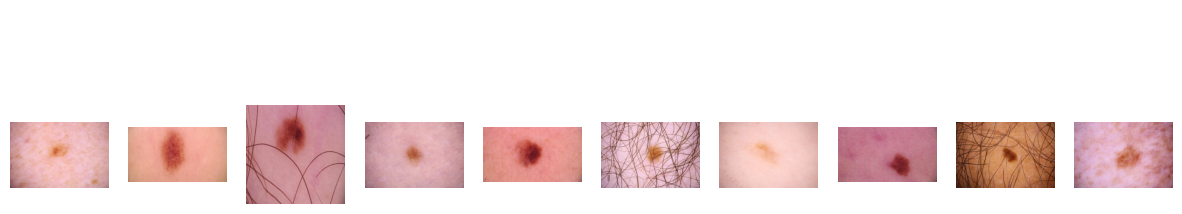

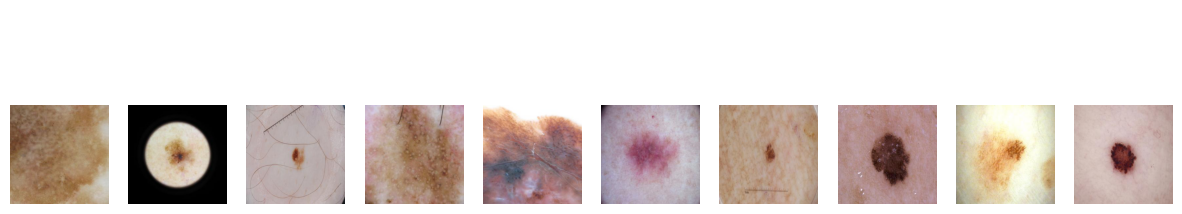

In [14]:
show_random_samples(df, 'benign', n = 10)
show_random_samples(df, 'malignant', n = 10)

# 2. Preprocessing pipeline

Images have two principal characteristics. One is the vignette, the other are the hair. We exploroe two simple approaches to deal with both.

## 2.1 Dealing with vignetting

In [ ]:
# Testing the function to detect vignette borders
from helper_functions import has_vignette_border, show_border_samples
from tqdm.contrib.concurrent import thread_map

results = thread_map(
    has_vignette_border, 
    df['file_path'].tolist(), 
    max_workers=6,
    desc="Detecting vignette borders"
)
df['has_vignette_border'] = results

# --- CLEAN CONSOLE PRINT START ---
counts = df['has_vignette_border'].value_counts()
vignette_count = counts.get(True, 0)
normal_count = counts.get(False, 0)
total = len(df)

# Dynamic fallback safety in case total is 0 to avoid ZeroDivisionError
vignette_pct = (vignette_count / total * 100) if total > 0 else 0
normal_pct = (normal_count / total * 100) if total > 0 else 0

print("\n" + "="*45)
print(f" Total Images Processed : {total:,}")
print(f" Vignette Detected      : {vignette_count:,} ({vignette_pct:.1f}%)")
print(f" No Vignette  : {normal_count:,} ({normal_pct:.1f}%)")
print("="*45 + "\n")

show_border_samples(df, n=5)

Detecting vignette borders:   0%|          | 0/39418 [00:00<?, ?it/s]

KeyboardInterrupt: 

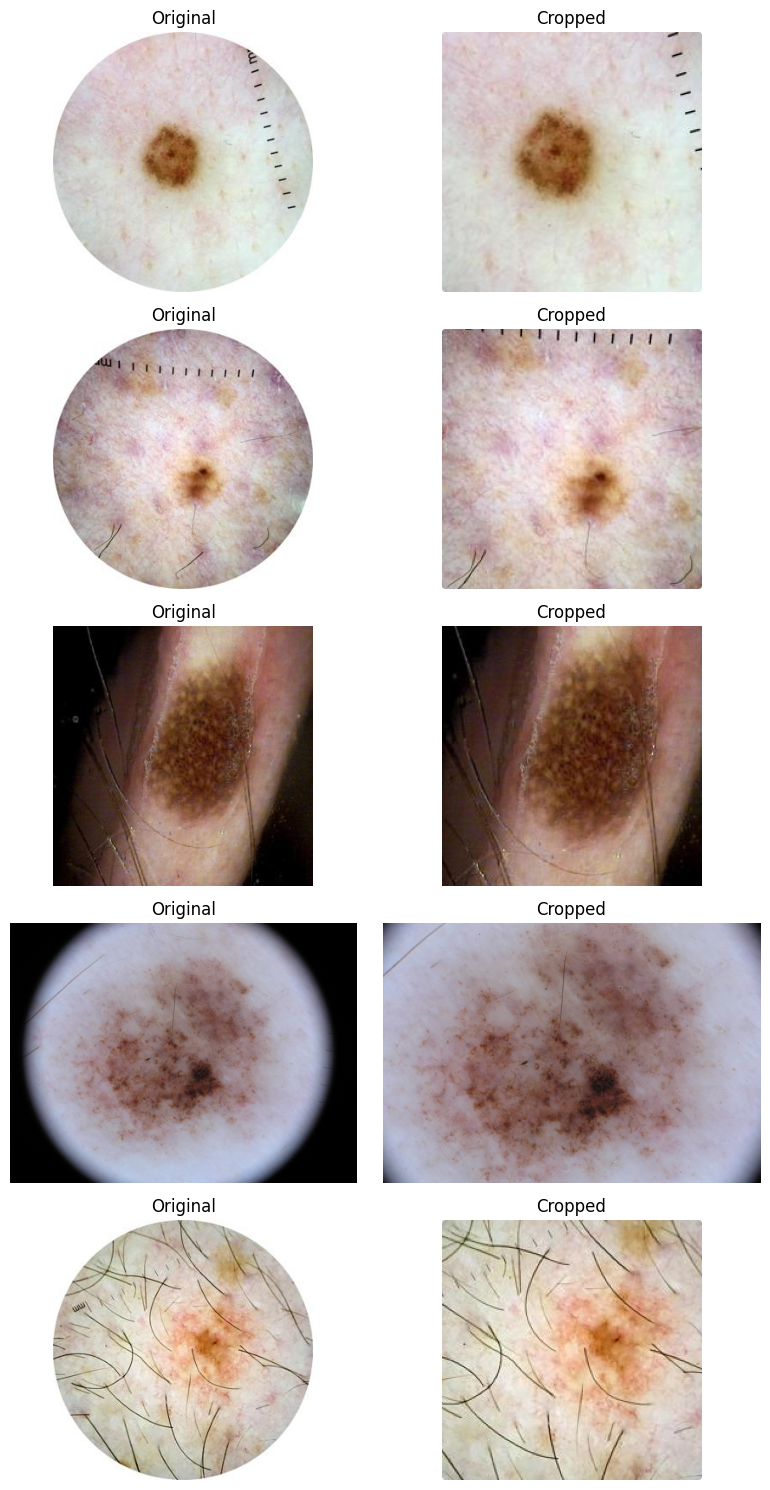

In [ ]:
# Testing the cropping handler function
from helper_functions import crop_border, crop_to_detected_circle, show_before_after_crop

testing = True
if(testing):
    subset_df = df[df['has_vignette_border']].copy()
    subset_df = subset_df.iloc[:50]
    subset_df['processed_img'] = subset_df.apply(
        lambda row: crop_to_detected_circle(row['file_path']) 
        if row['has_vignette_border'] else Image.open(row['file_path']),
        axis=1
    )
    show_before_after_crop(subset_df, n=5)
else:
    # No need to run that part, it will be dealt with during the training
    df['processed_vignetting'] = clean_df.apply(
        lambda row: crop_to_detected_circle(row['file_path']) if row['has_vignette_border'] 
        else Image.open(row['file_path']), axis=1)
    show_before_after_crop(clean_df, n=5)

## 2.1 Hair removal

Testing hair removal on 4 images...


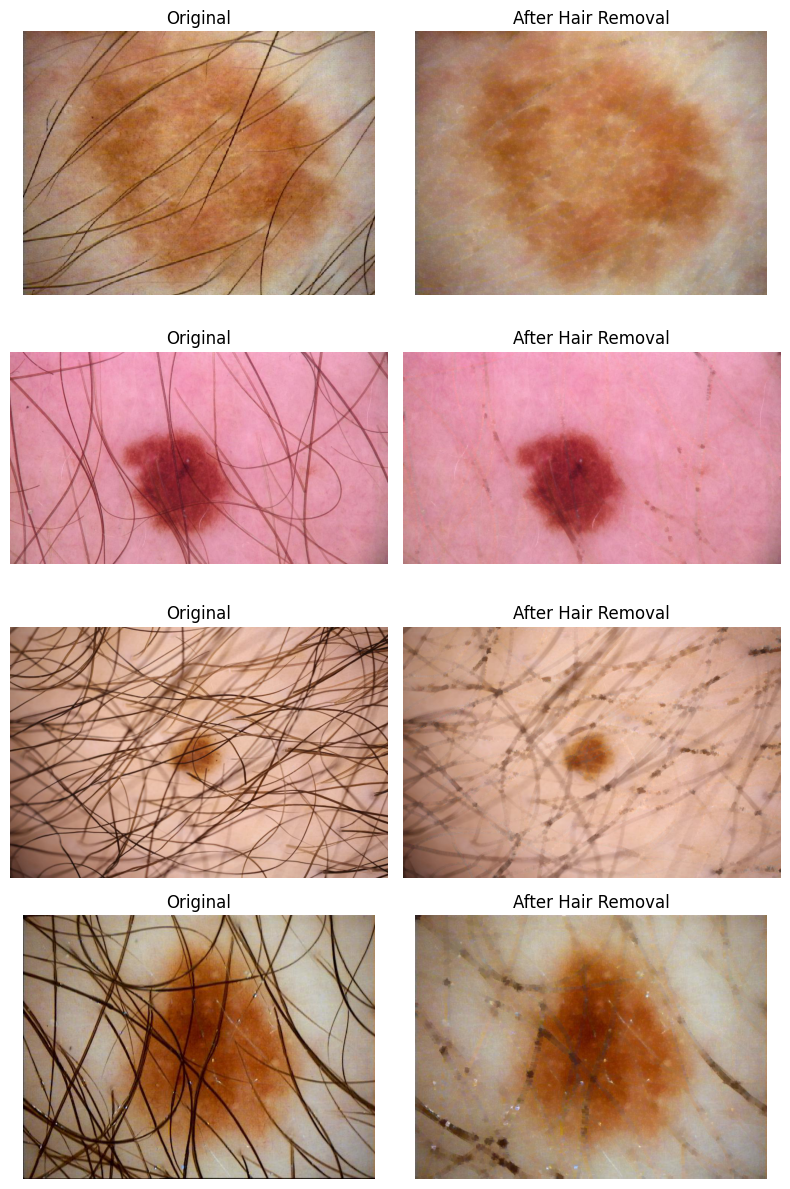

In [ ]:
from helper_functions import remove_hair, show_hair_removal_samples

testing = True

if testing:
    imgnumber = ["044574", "044433", "044246", "043909"]
    
    def matches_target(path):
        if not isinstance(path, str):
            return False
        base = os.path.basename(path)
        return any(num in base for num in imgnumber)

    subset_df = df[df['file_path'].apply(matches_target)].copy()
    # Run the hair removal via list comprehension (safe for image objects)
    subset_df['processed_hair'] = [
        remove_hair(Image.open(fp)) if (fp and os.path.exists(fp)) else None 
        for fp in subset_df['file_path']
    ]
    # Visual check
    show_hair_removal_samples(subset_df)

else:
    # Also no need to run that part
    def process_row_safe(fp):
        try:
            if fp and os.path.exists(fp):
                with Image.open(fp) as img:
                    return remove_hair(img.convert("RGB"))
        except Exception as e:
            print(f"Error processing {fp}: {e}")
        return None

    df['processed_hair'] = thread_map(
        process_row_safe, 
        df['file_path'].tolist(), 
        max_workers=8, 
        desc="Removing hair from all images"
    )
    


# 3. Model training

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, WeightedRandomSampler

import random
from datetime import datetime

import numpy as np

## 3.1 Framework definition

### 3.1.1 Model

In [ ]:
# Load a pretrained MobileNetV3 model (lightweight, fast, mobile-friendly)
def create_model(freeze_backbone=False):
    try:
      weights = models.MobileNet_V3_Small_Weights.DEFAULT
      model = models.mobilenet_v3_small(weights=weights)
    except Exception:
      print("Couldn't load pretrained weights, using random initialization instead.")
      model = models.mobilenet_v3_small(pretrained=True)

    # Replace final layer with one binary output (logit)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False  # freeze encoder

    return model.to(device)

# This function sets random seeds to make training reproducible
def set_seed(seed=33):
    random.seed(seed)                     
    np.random.seed(seed)                  
    torch.manual_seed(seed)                # PyTorch (CPU)
    if torch.cuda.is_available():          # PyTorch (GPU)
        torch.cuda.manual_seed_all(seed)

set_seed()  # you can change this value to re-randomize

# Use GPU if available (faster); otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device used: ", device)

model = create_model()


cpu


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [ ]:
from torchinfo import summary

# Define your input size matching your dataset (e.g., Batch Size 1, 3 Channels, 224x224)
# This simulates a pass through the network to calculate output dimensions
summary(model, input_size=(1, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"])

### 3.1.2 Train/Val split

In [ ]:
# # Class distribution
# output_csv = DATA_PATH+"./combined_labels.csv"
# df = pd.read_csv(output_csv)
# df["file_path"] = df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))

# # clean_df: your cleaned TRAIN dataframe (file_path, label)
# First split: train + temp_valtest
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,  # 30% reserved for val + test
    stratify=df['label'],
    random_state=35
)

# Second split: val + test from temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # half of 30% = 15% test, 15% val
    stratify=temp_df['label'],
    random_state=35
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

# (Optional) persist split for reproducibility
split_id = random.randint(10000, 99999)

# Step 4: Create dated folder with the split ID
today = datetime.today().strftime("%Y-%m-%d")
folder_name = f"../models/splits_{today}_{split_id}"
os.makedirs(folder_name, exist_ok=True)

# Step 5: Save train/val CSVs with split ID in filenames
train_df.to_csv(f"{folder_name}/split_{split_id}_train.csv", index=False)
val_df.to_csv(f"{folder_name}/split_{split_id}_val.csv", index=False)
test_df.to_csv(f"{folder_name}/split_{split_id}_test.csv", index=False)

print(f"✅ Split saved in folder '{folder_name}' with ID {split_id}")

Train size: 27592
Val size: 5913
Test size: 5913
✅ Split saved in folder '../models/splits_2026-05-18_84754' with ID 84754


We have way more benign then maignant, and the training must account for this imbalance

In [ ]:
# Imbalance 
counts = train_df['label'].value_counts()
neg, pos = int(counts.get('benign', 0)), int(counts.get('malignant', 0))
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

# Calculate distribution metrics
total = neg + pos
neg_pct = (neg / total * 100) if total > 0 else 0
pos_pct = (pos / total * 100) if total > 0 else 0

print("\n" + "="*50)
print(" DATASET IMBALANCE & LOSS WEIGHTING REPORT")
print("="*50)
print(f" Benign (Negative Class)    : {neg:,} ({neg_pct:.1f}%)")
print(f" Malignant (Positive Class) : {pos:,} ({pos_pct:.1f}%)")
print(f" Total Training Samples     : {total:,}")
print("-"*50)
print(f" Calculated pos_weight      : {pos_weight.item():.4f}")
print(f" Multiplier Ratio           : {pos_weight.item():.2f}:1")
print("="*50 + "\n")


Train counts: {'benign': np.int64(23937), 'malignant': np.int64(3655)} → pos_weight: 6.5491108894348145


In [7]:
# Loss with your computed pos_weight (from earlier cell)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

### 3.1.3 Preprocessing/augmentation pipeling definition

In [ ]:
from PIL import Image

IMG_SIZE = 224  #default for now
DO_VIGNETTE = False
DO_HAIR = False

class MelanomaDataset(Dataset):
    def __init__(self, df, transform, use_hair, use_vignette):
        self.paths = df['file_path'].tolist()
        self.labels = (df['label'] == 'malignant').astype('int64').tolist() #1 malignant, 0 benign
        self.transform = transform
        self.use_hair = use_hair
        self.use_vignette = use_vignette

    def __len__(self): 
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = preprocess_pil(p, do_vignette=self.use_vignette, do_hair=self.use_hair)
        img = self.transform(img)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, y

def preprocess_pil(img_path, do_vignette=DO_VIGNETTE, do_hair=DO_HAIR):
    img = Image.open(img_path).convert('RGB')
    if do_vignette and has_vignette_border(img_path):
        img = crop_to_detected_circle(img_path)  # your robust version
    if do_hair:
        img = remove_hair(img)   # inpainting-based
    return img

# this function
def estimate_norm(df, do_vignette, do_hair, n=600):
    paths = df.sample(min(n, len(df)), random_state=33)['file_path'].tolist()
    to_tensor = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])
    acc = []
    for p in paths:
        img = preprocess_pil(p, do_vignette=do_vignette, do_hair=do_hair)
        acc.append(to_tensor(img))
    stack = torch.stack(acc)
    return stack.mean(dim=(0,2,3)).tolist(), stack.std(dim=(0,2,3)).tolist()

### 3.1.4 Experiment run framework

In [ ]:
def run_experiment(recipe_name, do_vignette, do_hair, epochs=10):
    print(f"\n STARTING EXPERIMENT: {recipe_name} (Vignette={do_vignette}, Hair={do_hair})")
    
    # Calculate normalization stats tailored specifically to this pipeline recipe
    mean, std = estimate_norm(train_df, do_vignette=do_vignette, do_hair=do_hair, n=600)
    print("Norm stats (training set):", mean, std)
    
    # Define Transforms using these specifics, we could change some values, but we'll keep it simple
    train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), 
    T.RandomHorizontalFlip(),            
    T.RandomRotation(20), 
    T.ColorJitter(0.15, 0.15, 0.15, 0.08), # (brightness, contrast, saturation, hue).
    T.ToTensor(),                           
    T.Normalize(mean, std),                
])
    val_tfms = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean, std)
    ])
    
    # Create DataLoaders
    train_ds = MelanomaDataset(train_df, train_tfms, use_hair=do_hair, use_vignette=do_vignette)
    val_ds   = MelanomaDataset(val_df,   val_tfms,   use_hair=do_hair, use_vignette=do_vignette)
    
    labels = train_df['label'].values
    class_weights = [1. / np.sum(labels == label) for label in labels]
    sampler = WeightedRandomSampler(class_weights, len(class_weights))
    
    train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler, num_workers=6, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=6, pin_memory=False)
    
    # Initialize a clean model architecture instance for this run
    model = create_model().to(device)
    
    # Custom path for this model recipe's weights
    ckpt_path = folder_name+f"/model_{recipe_name}.pt"
    
    # Run fit loop (Passes mean/std explicitly to fit function so it saves correctly)
    print(f"Starting FIT")
    history, saved_path = fit(
        model, train_loader, val_loader, epochs=epochs, 
        ckpt_path=ckpt_path, patience=3
    )
    
    # history, ckpt = fit(model, train_loader, val_loader,
    #                 epochs=12, lr=1e-4, wd=1e-4, patience=3)
    # Convert history log to DataFrame and append recipe details
    history_df = pd.DataFrame(history)
    history_df["recipe"] = recipe_name
    
    return history_df
# This function runs on the validation set without updating the model

def evaluate(model, loader):
    model.eval()  # evaluation mode: disables dropout, etc.
    all_logits, all_y = [], []  # to collect predictions and true labels
    total_loss = 0.0

    with torch.no_grad():  # no gradients needed in eval
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)  # move to GPU/CPU
            logits = model(xb).squeeze(1)          # forward pass
            loss = loss_fn(logits, yb)
            total_loss += loss.item() * xb.size(0)

            all_logits.append(logits.cpu())        # store predictions
            all_y.append(yb.cpu())                 # store labels

    # Combine all batches
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy()

    # Convert logits to probabilities
    probs = 1 / (1 + np.exp(-logits))

    # Compute AUC (how well the model separates classes)
    try:
        auc = roc_auc_score(y_true, probs)
    except ValueError:
        auc = float('nan')

    # Compute PR-AUC (how good the model is at finding positives), important for imbalanced datasets
    try:
        pr_auc = average_precision_score(y_true, probs)
    except ValueError:
        pr_auc = float('nan')

    avg_loss = total_loss / len(loader.dataset)
    return {"loss": avg_loss, "auc": auc, "pr_auc": pr_auc}

def train_one_epoch(model, loader, optimizer, scaler=None):
    model.train()  # set model to training mode
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        print("Batch:", xb.shape, yb.shape, "malignant frac in batch:", float(yb.mean().item()))
        optimizer.zero_grad(set_to_none=True)  # reset gradients

        if scaler is None:  # standard training (no mixed precision)
            logits = model(xb).squeeze(1)  # get predictions
            loss = loss_fn(logits, yb)
            loss.backward()               # compute gradients
            optimizer.step()              # update weights
        else:  # mixed precision for faster training on GPU
            with torch.cuda.amp.autocast():
                logits = model(xb).squeeze(1)
                loss = loss_fn(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * xb.size(0)  # accumulate batch loss

    return total_loss / len(loader.dataset)  # average over all data



def fit(model, train_loader, val_loader, epochs=10, lr=1e-4, wd=1e-4,
        patience=3, ckpt_path="models/baseline_mnv3.pt"):

    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scaler = torch.amp.GradScaler() if device.type == 'cuda' else None

    best_auc = -float('inf')
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        val_metrics = evaluate(model, val_loader)
        history.append({"epoch": epoch, "train_loss": tr_loss, **val_metrics})

        # Save best model based on val AUC
        improved = val_metrics["pr_auc"] > best_auc
        if improved:
            best_auc = val_metrics["pr_auc"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            torch.save({"state_dict": best_state, "mean": mean, "std": std}, ckpt_path)
            wait = 0  # reset patience counter
        else:
            wait += 1

        dt = time.time() - t0
        print(f"Epoch {epoch:02d} | tr_loss {tr_loss:.4f} | val_loss {val_metrics['loss']:.4f} | "
              f"val_auc {val_metrics['auc']:.4f} | val_prAUC {val_metrics['pr_auc']:.4f} | {dt:.1f}s"
              + ("  *" if improved else ""))

        if wait >= patience:
            print(f"Early stopping (no AUC improvement for {patience} epochs).")
            break

    # Load best model back into memory
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, ckpt_path



 STARTING EXPERIMENT: baseline (Vignette=False, Hair=False)
Norm stats (training set): [0.7747164368629456, 0.5970910787582397, 0.5691449642181396] [0.18039999902248383, 0.19212715327739716, 0.21069513261318207]
Starting FIT


In [ ]:
class MelanomaDataset(Dataset):
    def __init__(self, df, transform, use_hair=DO_HAIR, use_vignette=DO_VIGNETTE):
        self.paths  = df['file_path'].tolist()
        self.labels = (df['label'] == 'malignant').astype('int64').tolist()
        self.transform = transform
        self.use_hair = use_hair
        self.use_vignette = use_vignette

    def __len__(self): 
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = preprocess_pil(p, do_vignette=self.use_vignette, do_hair=self.use_hair)
        img = self.transform(img)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)  # BCEWithLogitsLoss expects float
        return img, y

# Compute class weights
labels = train_df['label'].values
class_weights = [1. / np.sum(labels == label) for label in labels]

# Sampler
sampler = WeightedRandomSampler(class_weights, len(class_weights))


train_ds = MelanomaDataset(train_df, train_tfms, use_hair=DO_HAIR, use_vignette=DO_VIGNETTE)
val_ds   = MelanomaDataset(val_df,   val_tfms,   use_hair=DO_HAIR, use_vignette=DO_VIGNETTE)

train_loader = DataLoader(train_ds, batch_size=32, sampler = sampler, num_workers=2, pin_memory=False) #shuffle=False, 
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=False)

# quick sanity check
xb, yb = next(iter(train_loader))
print("Batch:", xb.shape, yb.shape, "malignant frac in batch:", float(yb.mean().item()))


Batch: torch.Size([32, 3, 224, 224]) torch.Size([32]) malignant frac in batch: 0.46875


## 3.2 Training

### Create Model

In [ ]:
# 1. Define recipes: (Name, DO_VIGNETTE, DO_HAIR)
recipes = [
    ("baseline",        False, False),
    ("vignette_only",   True,  False),
    ("hair_only",       False, True),
    ("full_processed",  True,  True)
]

all_results = []

# 2. Iterate and train
for name, vig, hair in recipes:
    res_df = run_experiment(recipe_name=name, do_vignette=vig, do_hair=hair, epochs=10)
    all_results.append(res_df)

# 3. Concatenate and sort to see which preprocessing strategy wins!
comparison_df = pd.concat(all_results, ignore_index=True)

# Find the best epoch result for each recipe based on Validation PR-AUC
best_per_recipe = comparison_df.sort_values("val_pr_auc", ascending=False).drop_duplicates(["recipe"])
print("\n FINAL RECIPE COMPARISON LEADERBOARD:")
print(best_per_recipe[["recipe", "epoch", "train_loss", "loss", "auc", "val_pr_auc"]])

Epoch 01 | tr_loss 0.4977 | val_loss 0.5110 | val_auc 0.9889 | val_prAUC 0.9510 | 279.6s  *
Epoch 02 | tr_loss 0.3405 | val_loss 0.4187 | val_auc 0.9892 | val_prAUC 0.9563 | 276.7s  *
Epoch 03 | tr_loss 0.2739 | val_loss 0.3345 | val_auc 0.9905 | val_prAUC 0.9612 | 270.2s  *
Epoch 04 | tr_loss 0.2299 | val_loss 0.2403 | val_auc 0.9916 | val_prAUC 0.9631 | 282.6s  *
Epoch 05 | tr_loss 0.1988 | val_loss 0.2904 | val_auc 0.9919 | val_prAUC 0.9649 | 274.6s  *
Epoch 06 | tr_loss 0.1664 | val_loss 0.2499 | val_auc 0.9918 | val_prAUC 0.9661 | 288.1s
Epoch 07 | tr_loss 0.1470 | val_loss 0.2387 | val_auc 0.9919 | val_prAUC 0.9654 | 262.4s  *
Epoch 08 | tr_loss 0.1349 | val_loss 0.2826 | val_auc 0.9916 | val_prAUC 0.9662 | 271.5s
Epoch 09 | tr_loss 0.1198 | val_loss 0.2748 | val_auc 0.9916 | val_prAUC 0.9661 | 277.7s
Epoch 10 | tr_loss 0.1111 | val_loss 0.2588 | val_auc 0.9926 | val_prAUC 0.9682 | 288.2s  *
Epoch 11 | tr_loss 0.1027 | val_loss 0.3388 | val_auc 0.9905 | val_prAUC 0.9617 | 272.5s


In [195]:
filename = f"{folder_name}/{split_id}_mole_classifier.pth"
torch.save(model.state_dict(), filename)


## Check validation performance

In [196]:
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
import seaborn as sns

def evaluate_on_val(model, val_loader, threshold=0.5, device='cpu'):
    model.eval()
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images).squeeze(1)        # shape [B]
            probs = torch.sigmoid(logits)            # convert logits to probabilities
            preds = (probs >= threshold).int()       # threshold at 0.5

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix @ Threshold = {threshold:.2f}')
    plt.show()

    print()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["benign", "malignant"]))

    return y_true, y_pred, y_score


Confusion Matrix:


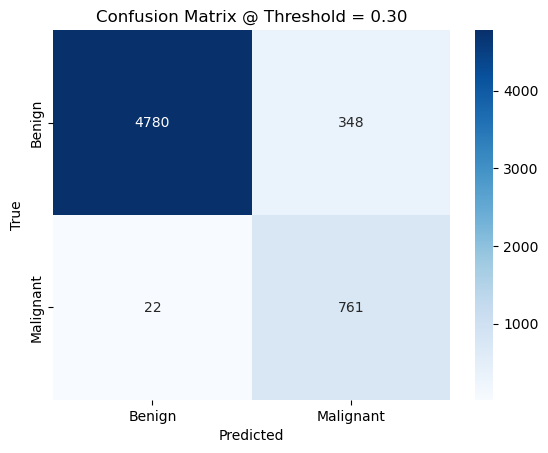



Classification Report:
              precision    recall  f1-score   support

      benign       1.00      0.93      0.96      5128
   malignant       0.69      0.97      0.80       783

    accuracy                           0.94      5911
   macro avg       0.84      0.95      0.88      5911
weighted avg       0.95      0.94      0.94      5911



In [ ]:
checkpoint = torch.load(ckpt)
model.load_state_dict(checkpoint['state_dict'])  # load just the weights
y_true, y_pred, y_score = evaluate_on_val(model, val_loader, threshold=0.5)

In [198]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
def plot_roc_pr_curves(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # ROC Curve
    axs[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axs[0].plot([0, 1], [0, 1], 'k--')
    axs[0].set_title("ROC Curve")
    axs[0].set_xlabel("False Positive Rate")
    axs[0].set_ylabel("True Positive Rate")
    axs[0].legend()

    # Precision-Recall Curve
    axs[1].plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}", color="darkorange")
    axs[1].set_title("Precision–Recall Curve")
    axs[1].set_xlabel("Recall")
    axs[1].set_ylabel("Precision")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


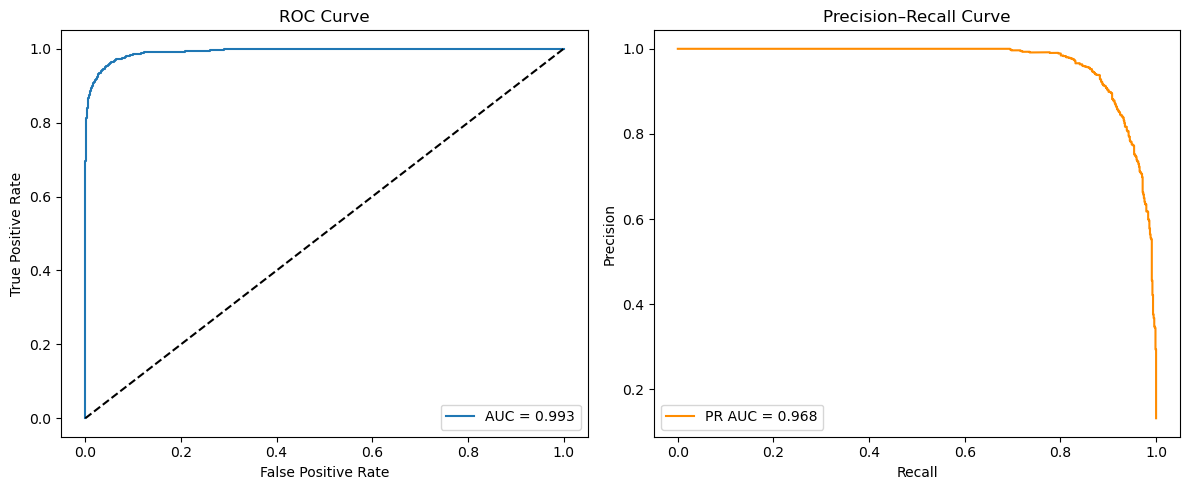

In [199]:
plot_roc_pr_curves(y_true, y_score)



In [200]:
def show_misclassified(df, y_true, y_pred, kind="fp", max_imgs=6):
    """
    kind = "fp" (false positives) → predicted malignant, actually benign
         = "fn" (false negatives) → predicted benign, actually malignant
    """
    mismatches = []
    for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
        if kind == "fp" and yt == 0 and yp == 1:
            mismatches.append(i)
        elif kind == "fn" and yt == 1 and yp == 0:
            mismatches.append(i)

    print(f"Found {len(mismatches)} {kind.upper()}s.")
    if not mismatches:
        return

    indices = mismatches[:max_imgs]
    fig, axs = plt.subplots(1, len(indices), figsize=(15, 5))
    for ax, idx in zip(axs, indices):
        path = df.iloc[idx]['file_path']
        ax.imshow(Image.open(path))
        ax.axis('off')
        ax.set_title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.show()


Found 348 FPs.


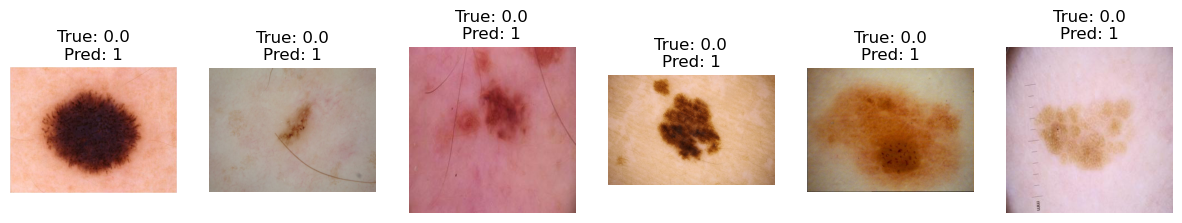

Found 22 FNs.


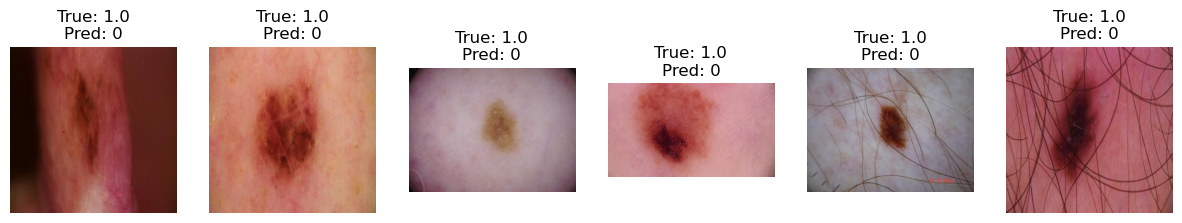

In [201]:
show_misclassified(val_df, y_true, y_pred, kind="fp")  # False Positives
show_misclassified(val_df, y_true, y_pred, kind="fn")  # False Negatives


In [175]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_threshold(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold = {threshold:.2f}")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1 Score:  {f1:.3f}")

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix @ Threshold = {threshold:.2f}')
    plt.show()




Threshold = 0.30
Accuracy:  0.937
Precision: 0.686
Recall:    0.972
F1 Score:  0.804


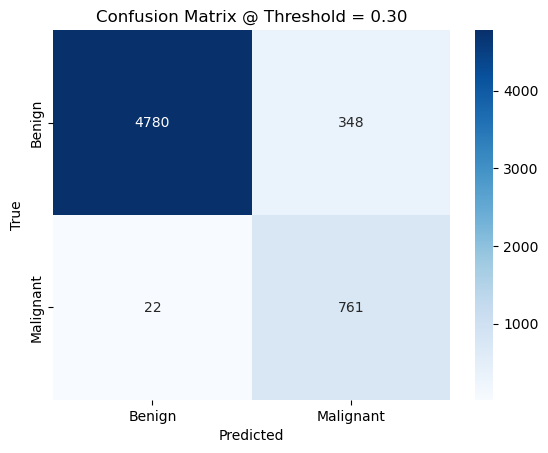


Threshold = 0.50
Accuracy:  0.949
Precision: 0.733
Recall:    0.963
F1 Score:  0.833


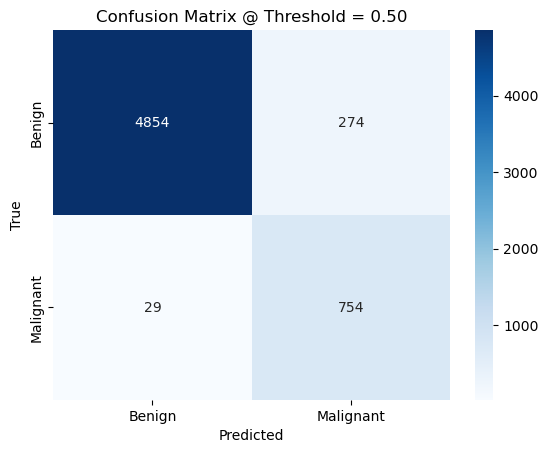


Threshold = 0.70
Accuracy:  0.958
Precision: 0.784
Recall:    0.945
F1 Score:  0.857


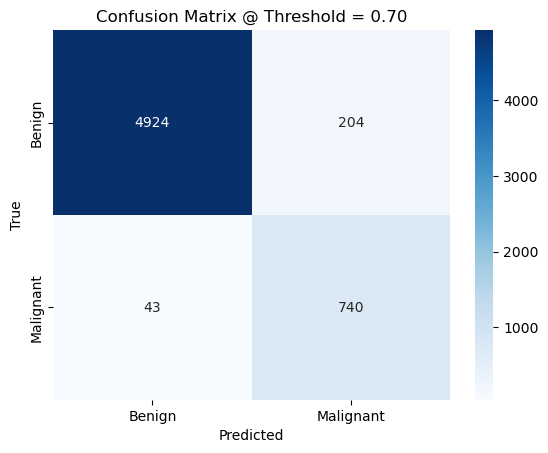

In [202]:
for t in [0.3, 0.5, 0.7]:
    evaluate_threshold(y_true, y_score, threshold=t)


## Test sample

In [203]:
checkpoint = torch.load(ckpt)
model.load_state_dict(checkpoint['state_dict'])  # load just the weights
model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [204]:
from torch.utils.data import Dataset
from PIL import Image

class CustomDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = preprocess_pil(row['file_path'], do_vignette=True, do_hair=False)
        label = 1 if row['label'] == 'malignant' else 0

        if self.transform:
            image = self.transform(image)

        return image, label

In [205]:
test_dataset = CustomDataset(test_df, transform=val_tfms)  # same transforms as validation
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [206]:
def evaluate_on_test(model, test_loader, threshold=0.5):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb).squeeze(1)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).int()

            y_true.append(yb.cpu())
            y_pred.append(preds.cpu())
            y_score.append(probs.cpu())

    return (
        torch.cat(y_true).numpy(),
        torch.cat(y_pred).numpy(),
        torch.cat(y_score).numpy()
    )


In [213]:
y_true_test, y_pred_test, y_score_test = evaluate_on_test(model, test_loader, threshold=0.5)

In [214]:
from sklearn.metrics import classification_report, confusion_matrix

print("Test Set Results")
print(confusion_matrix(y_true_test, y_pred_test))
print(classification_report(y_true_test, y_pred_test, target_names=["Benign", "Malignant"]))


Test Set Results
[[4862  267]
 [  27  756]]
              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      5129
   Malignant       0.74      0.97      0.84       783

    accuracy                           0.95      5912
   macro avg       0.87      0.96      0.90      5912
weighted avg       0.96      0.95      0.95      5912



In [209]:
import matplotlib.pyplot as plt

def show_predictions_by_type(model, dataloader, df_ori, threshold=0.5, n_per_type=4):
    model.eval()
    all_preds, all_probs, all_labels, all_paths = [], [], [], []

    with torch.no_grad():
        for (x, y) in dataloader:
            x = x.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits).squeeze().cpu()
            preds = (probs > threshold).int()
            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())
            all_labels.extend(y.tolist())

    # Match with paths
    df = df_ori.copy().reset_index(drop=True)
    df['pred'] = all_preds
    df['prob'] = all_probs
    df['true'] = all_labels

    def sample_and_plot(label, pred, title):
        samples = df[(df['true'] == label) & (df['pred'] == pred)].sample(n=min(n_per_type, sum((df['true'] == label) & (df['pred'] == pred))), random_state=42)
        fig, axes = plt.subplots(1, len(samples), figsize=(15, 4))
        fig.suptitle(title, fontsize=16)
        for ax, (_, row) in zip(axes, samples.iterrows()):
            img = Image.open(row['file_path'])
            ax.imshow(img)
            ax.set_title(f"p={row['prob']:.2f}")
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    sample_and_plot(1, 1, "True Positives (Malignant predicted correctly)")
    sample_and_plot(0, 0, "True Negatives (Benign predicted correctly)")
    sample_and_plot(0, 1, "False Positives (Benign predicted malignant)")
    sample_and_plot(1, 0, "False Negatives (Malignant predicted benign)")


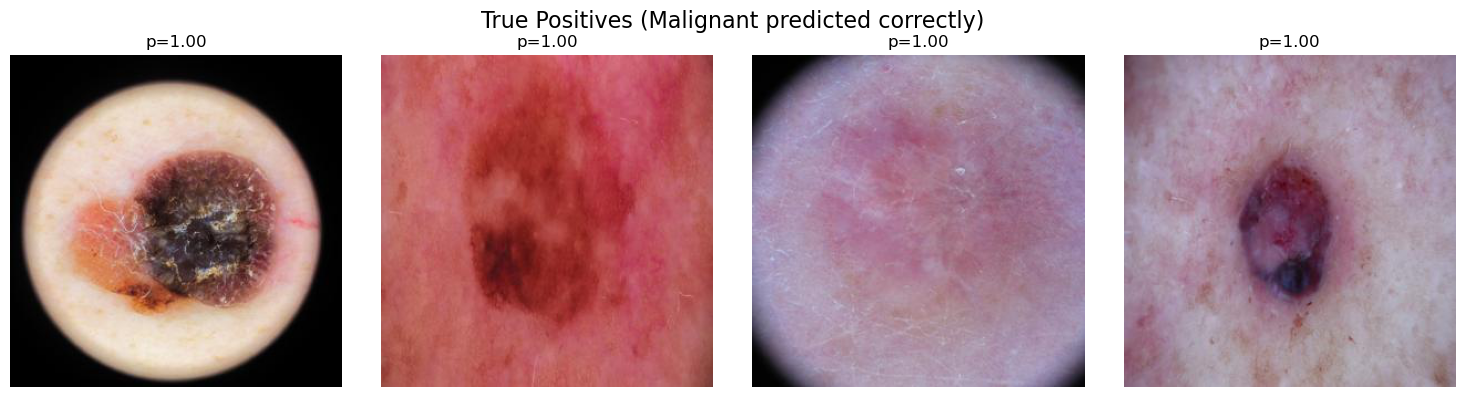

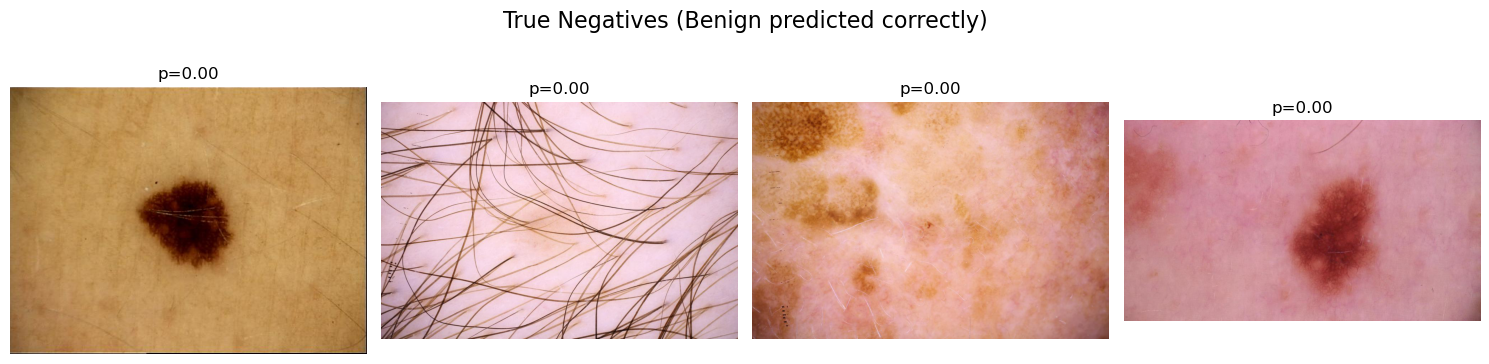

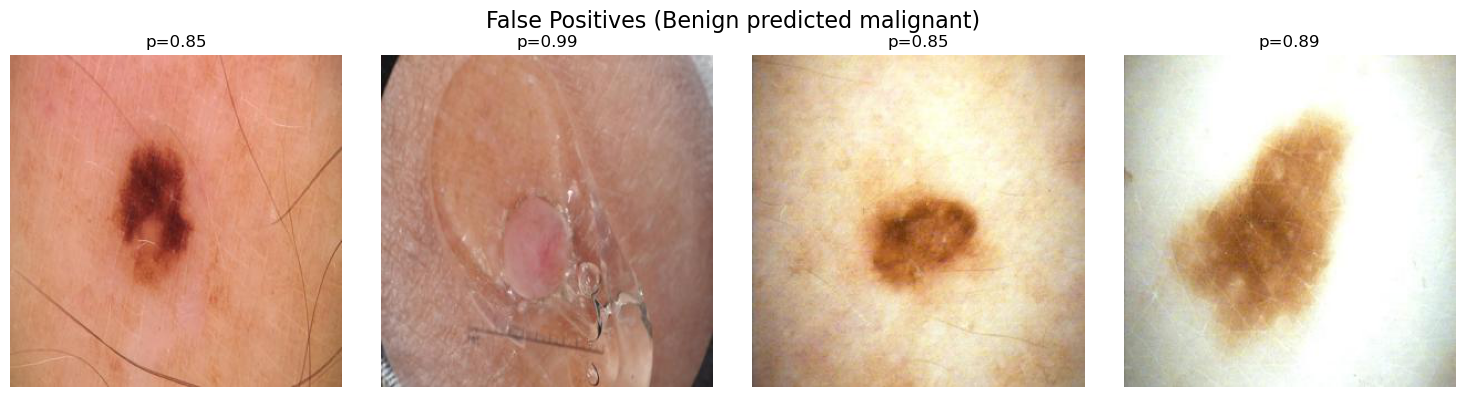

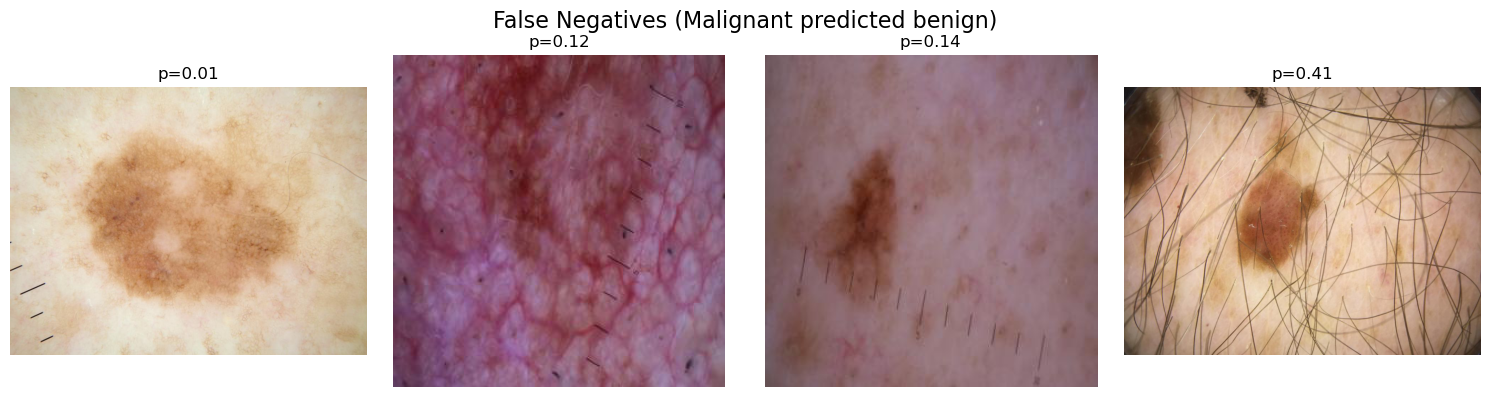

In [211]:
show_predictions_by_type(model, test_loader, test_df,threshold=0.5, n_per_type=4)

# Testing on a different data set